<a href="https://colab.research.google.com/github/jahnavikrishnakancharla/-Lack-of-Access-to-Quality-Learning-Resources-/blob/main/BRAIN_STROKE_PREDICTION_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(5110, 12)


In [ ]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [ ]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [ ]:
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


/tmp/ipykernel_3300/4109061988.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [ ]:
encoder = LabelEncoder()

columns = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

for col in columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [ ]:
df = df.drop("id", axis=1)

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [ ]:
X = df.drop("stroke", axis=1)

y = df["stroke"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4088, 10)
(1022, 10)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained")

Logistic Regression Model Trained


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.9393346379647749

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022


Confusion Matrix:
[[960   0]
 [ 62   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.9383561643835616


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy:
0.9344422700587084


In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

SVM Accuracy:
0.9393346379647749


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:")
print(accuracy_score(y_test, y_pred_mlp))

MLP Accuracy:
0.9393346379647749


In [ ]:
results = {
    "Logistic Regression":
        accuracy_score(y_test, y_pred),

    "Random Forest":
        accuracy_score(y_test, y_pred_rf),

    "KNN":
        accuracy_score(y_test, y_pred_knn),

    "SVM":
        accuracy_score(y_test, y_pred_svm),

    "MLP":
        accuracy_score(y_test, y_pred_mlp)
}

for model, score in results.items():
    print(model, ":", round(score*100,2), "%")

Logistic Regression : 93.93 %
Random Forest : 93.84 %
KNN : 93.44 %
SVM : 93.93 %
MLP : 93.93 %


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
def evaluate_model(name, y_test, y_pred, y_prob):

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", round(accuracy_score(y_test,y_pred)*100,2),"%")

    print("Precision :", round(precision_score(y_test,y_pred)*100,2),"%")

    print("Recall :", round(recall_score(y_test,y_pred)*100,2),"%")

    print("F1 Score :", round(f1_score(y_test,y_pred)*100,2),"%")

    print("ROC-AUC :", round(roc_auc_score(y_test,y_prob)*100,2),"%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test,y_pred))

In [ ]:
# Logistic Regression
lr_prob = lr.predict_proba(X_test)[:,1]

# Random Forest
rf_prob = rf.predict_proba(X_test)[:,1]

# KNN
knn_prob = knn.predict_proba(X_test)[:,1]

# MLP
mlp_prob = mlp.predict_proba(X_test)[:,1]

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    lr_prob
)


evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    rf_prob
)


evaluate_model(
    "KNN",
    y_test,
    y_pred_knn,
    knn_prob
)


evaluate_model(
    "MLP Neural Network",
    y_test,
    y_pred_mlp,
    mlp_prob
)


Logistic Regression
Accuracy : 93.93 %
Precision : 0.0 %
Recall : 0.0 %
F1 Score : 0.0 %
ROC-AUC : 85.13 %

Confusion Matrix:
[[960   0]
 [ 62   0]]

Random Forest
Accuracy : 93.84 %
Precision : 0.0 %
Recall : 0.0 %
F1 Score : 0.0 %
ROC-AUC : 81.12 %

Confusion Matrix:
[[959   1]
 [ 62   0]]

KNN
Accuracy : 93.44 %
Precision : 0.0 %
Recall : 0.0 %
F1 Score : 0.0 %
ROC-AUC : 65.47 %

Confusion Matrix:
[[955   5]
 [ 62   0]]

MLP Neural Network
Accuracy : 93.93 %
Precision : 0.0 %
Recall : 0.0 %
F1 Score : 0.0 %
ROC-AUC : 78.88 %

Confusion Matrix:
[[960   0]
 [ 62   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


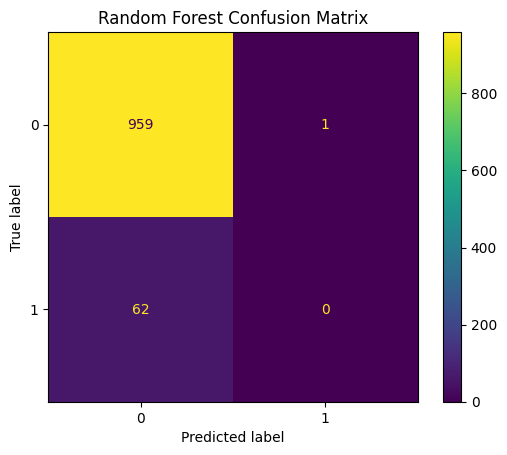

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()

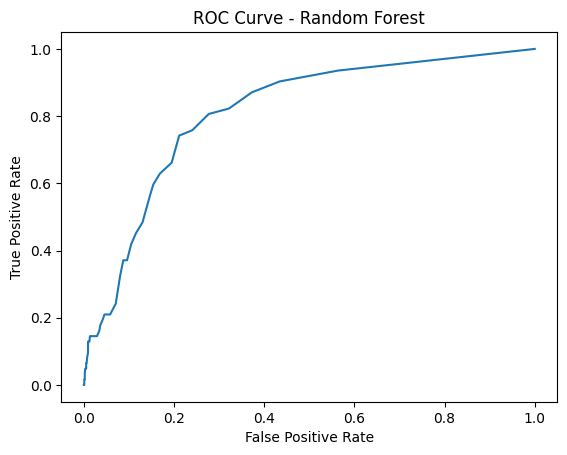

In [ ]:
from sklearn.metrics import roc_curve


fpr, tpr, threshold = roc_curve(
    y_test,
    rf_prob
)

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import datetime


# Load trained model
model = joblib.load("stroke_model.pkl")


# Page title
st.title("🧠 Brain Stroke Prediction Agent")

st.write(
"""
Doctor Dashboard for Stroke Risk Assessment
"""
)


# Patient Inputs

gender = st.selectbox(
    "Gender",
    ["Female","Male"]
)


age = st.number_input(
    "Age",
    1,
    100,
    50
)


hypertension = st.selectbox(
    "Hypertension",
    [0,1],
    format_func=lambda x:
    "No" if x==0 else "Yes"
)


heart = st.selectbox(
    "Heart Disease",
    [0,1],
    format_func=lambda x:
    "No" if x==0 else "Yes"
)


married = st.selectbox(
    "Ever Married",
    ["No","Yes"]
)


work = st.selectbox(
    "Work Type",
    [
    "Private",
    "Self-employed",
    "Government",
    "Children",
    "Never_worked"
    ]
)


residence = st.selectbox(
    "Residence Type",
    ["Rural","Urban"]
)


glucose = st.number_input(
    "Average Glucose Level",
    50.0,
    300.0,
    100.0
)


bmi = st.number_input(
    "BMI",
    10.0,
    60.0,
    25.0
)


smoking = st.selectbox(
    "Smoking Status",
    [
    "never smoked",
    "formerly smoked",
    "smokes",
    "Unknown"
    ]
)



# Encoding

gender = 1 if gender=="Male" else 0

married = 1 if married=="Yes" else 0

residence = 1 if residence=="Urban" else 0


work_map = {
"Private":2,
"Self-employed":3,
"Government":0,
"Children":1,
"Never_worked":4
}

work = work_map[work]


smoke_map = {
"never smoked":2,
"formerly smoked":1,
"smokes":3,
"Unknown":0
}

smoking = smoke_map[smoking]



# Prediction Button

if st.button("Predict Stroke Risk"):


    patient = pd.DataFrame([{

    "gender":gender,
    "age":age,
    "hypertension":hypertension,
    "heart_disease":heart,
    "ever_married":married,
    "work_type":work,
    "Residence_type":residence,
    "avg_glucose_level":glucose,
    "bmi":bmi,
    "smoking_status":smoking

    }])


    prediction = model.predict(patient)[0]

    probability = model.predict_proba(patient)[0][1]


    st.subheader("Stroke Risk Report")


    if probability <0.3:

        risk="Low Risk"

    elif probability<0.7:

        risk="Medium Risk"

    else:

        risk="High Risk"



    st.write(
    "Prediction:",
    "Stroke" if prediction==1 else "No Stroke"
    )


    st.write(
    "Risk Percentage:",
    round(probability*100,2),
    "%"
    )


    st.write(
    "Risk Level:",
    risk
    )


    # Recommendations

    st.subheader("Recommendations")


    if risk=="High Risk":

        st.warning(
        """
        • Consult doctor immediately
        • Monitor blood pressure
        • Maintain healthy lifestyle
        """
        )


    elif risk=="Medium Risk":

        st.info(
        """
        • Regular checkup
        • Exercise daily
        • Control glucose level
        """
        )

    else:

        st.success(
        "Maintain healthy lifestyle"
        )


    # Save monitoring

    record = patient.copy()

    record["prediction"] = prediction

    record["risk"] = risk

    record["time"] = datetime.datetime.now()


    record.to_csv(
    "monitoring_records.csv",
    mode="a",
    header=False,
    index=False
    )


    st.success(
    "Patient record saved"
    )

Writing app.py


In [ ]:
%%shell
npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
%%shell
streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧your url is: https://dark-parrots-judge.loca.lt
2026-06-24 09:20:06.967 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.32.138.207:8501

  Stopping...


CalledProcessError: Command 'streamlit run app.py & npx localtunnel --port 8501
' died with <Signals.SIGINT: 2>.

In [ ]:
You can now view your Streamlit app in your browser.

Local URL: http://localhost:8501

SyntaxError: invalid syntax (3752928766.py, line 1)